# L2-SP sweep — quality vs labelling budget

Reads `results/l2sp_sweep/l2sp_tau_sweep.csv` (stage 3) and puts it next to the
model-free lookup baseline.

## What is plotted, and in what order

1. **The sweep's own figure, reproduced** — set-MAE vs K, one line per tau, with the
   unadapted population model (K=0) as a dashed floor. Same construction as
   `sweep_l2sp_tau.summarize` so the notebook and the PNG cannot drift apart.
2. **The same curves minus the deployable lookup**, which is the question that
   actually matters: the lookup wins at every K on this cohort, so what decides
   whether personalization is worth anything is whether the *gap* closes as labels
   accumulate.
3. **Both again in set-accuracy**, because MAE and accuracy answer different
   questions here and the live study's satisfaction rating is closer to accuracy —
   "did the system pick something I would accept" — than to mean distance.

## The comparison has to be protocol-matched, and that is not free

`sweep_l2sp_tau` scores every K on a FIXED tail: the chronologically last
`--val-frac` of a driver's segments, with the support drawn as the first K of the
remaining pool. `baseline_lookup.py` writes two columns and NEITHER matches it —
`set_mae` uses the suffix protocol (query = everything after K, so the query moves
with K) and `set_mae_tail` uses a fixed *count* of 30 rather than a fraction.

Reading those numbers against the sweep would compare different test sets. So the
lookup is recomputed here on the sweep's exact protocol, importing
`build_table`/`predict` from `baseline_lookup` rather than reimplementing them, so
"lookup" means the same rule in both places and only the evaluation set changes.

## Two caveats that bound how hard these curves can be read

* **tau=20 in `selected_tau.json` is a tie-break artifact.** The mean is monotone
  in tau — 0.05 is best and 100 worst — but the rule takes the largest tau within
  one BETWEEN-DRIVER SE, and that SE (0.094) is wide enough to admit seven of the
  eight values. Driver difficulty spans ~1.0 while tau effects are ~0.08, so the
  unpaired SE is the wrong yardstick.
* **385 of 1744 cells did not converge** (`|grad| > 1e-3`), concentrated at the
  extreme taus and, for tau=0.05, at large K. The Laplace layer expands about the
  MAP, so those cells are not merely undertrained. Every plot below marks the
  converged fraction; treat the large-K end of tau=0.05 as provisional until the
  sweep is re-run with more steps.

In [25]:
import sys, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not reimplemented: the lookup must be the SAME rule here as in
# baseline_lookup.py, or "the gap to the lookup" is a gap to something else.
from ProVoice.training_scripts.baseline_lookup import (
    best_constant, build_table, load_labels, predict,
)

%matplotlib inline
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = _SRC.parent
SWEEP_CSV = ROOT / "results/l2sp_sweep/l2sp_tau_sweep.csv"
LABELS_CSV = ROOT / "data/user_loa_labels.csv"
VAL_FRAC = 0.3        # MUST match the --val-frac the sweep ran with
K_CAP = 60
GRAD_OK = 1e-3        # sweep_l2sp_tau.GRAD_NORM_WARN

df = pd.read_csv(SWEEP_CSV, dtype={"pid": str})
print(f"{len(df)} rows | {df.pid.nunique()} drivers | taus {sorted(df.tau.unique())}")
print(f"K values: {sorted(df.k.unique())}")
print(f"converged (|grad| <= {GRAD_OK:g}): {(df.grad_norm <= GRAD_OK).mean():.1%} of cells")
print(f"unadapted population floor (K=0): set-MAE {df.base_set_mae.mean():.3f} "
      f"| set-acc {df.base_set_acc.mean():.3f}")

1744 rows | 12 drivers | taus [0.05, 0.2, 0.5, 1.0, 2.0, 5.0, 20.0, 100.0]
K values: [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20, 25, 30, 40, 50, 60, 75, 90]
converged (|grad| <= 0.001): 77.9% of cells
unadapted population floor (K=0): set-MAE 1.596 | set-acc 0.261


In [26]:
# ---------------- the lookup, recomputed on the SWEEP's protocol

def lookup_on_sweep_protocol(labels_csv: pathlib.Path, ks, val_frac: float,
                             variant: str = "driver_function",
                             min_cell: int = 1) -> pd.DataFrame:
    """Per-(driver, function) lookup, scored exactly the way the sweep scores.

    support = the driver's first K segments; query = their chronologically last
    ``val_frac`` — the same split `sweep_l2sp_tau.sweep_driver` uses, so the two
    curves are measured on identical rows and can be subtracted.

    Returns one row per (pid, k) with set_mae and set_acc, matching the sweep's
    column names so a join is trivial.
    """
    lab = load_labels(labels_csv)
    out = []
    for pid, g in lab.groupby("participantid"):
        g = g.reset_index(drop=True)
        n = len(g)
        n_val = max(1, round(val_frac * n))
        pool, query = g.iloc[: n - n_val], g.iloc[n - n_val:]
        q_lv = np.stack(query["marks"].to_numpy())
        for k in ks:
            if k > len(pool):
                continue          # this driver has no such prefix; leave the cell empty
            table, driver_c = build_table(pool.iloc[:k], min_cell)
            if driver_c is None:
                continue
            pred, _ = predict(query, table, driver_c, variant)
            out.append({"pid": str(pid), "k": int(k),
                        "lk_set_mae": float(set_mae_(q_lv, pred)),
                        "lk_set_acc": float(set_acc_(q_lv, pred))})
    return pd.DataFrame(out)


# The metric functions the whole project uses; imported here rather than
# re-derived so "set-MAE" means one thing across every table in the thesis.
from ProVoice.models.train_XLSTM import set_accuracy as set_acc_, set_mae as set_mae_

KS = sorted(df.k.unique())
LK = lookup_on_sweep_protocol(LABELS_CSV, KS, VAL_FRAC)
print(f"lookup recomputed for {LK.pid.nunique()} drivers x {LK.k.nunique()} K values")

# Join on (pid, k): every comparison below is WITHIN a driver at a fixed K, which
# is what cancels driver difficulty (per-driver floors span ~0.5 to ~1.6).
M = df.merge(LK, on=["pid", "k"], how="left")
print(f"rows with a matched lookup value: {M.lk_set_mae.notna().mean():.1%}")

lookup recomputed for 12 drivers x 19 K values
rows with a matched lookup value: 100.0%


In [27]:
# ------------------------------------------------ shared plotting helpers

def _tau_colours(taus):
    cmap = plt.get_cmap("viridis")
    return {t: cmap(i / max(1, len(taus) - 1)) for i, t in enumerate(sorted(taus))}


def coverage(sub: pd.DataFrame) -> pd.Series:
    """Drivers contributing at each K. Above the cap only the long drivers have
    data, so the mean there is a different (and smaller) cohort — drawn, but the
    reader has to be able to see it."""
    return sub.groupby("k").pid.nunique()


def plot_vs_k(data: pd.DataFrame, value: str, ylabel: str, title: str,
              floor: float = None, floor_label: str = None,
              zero_line: bool = False, selected_tau: float = None,
              ax=None, min_drivers: int = None, agg: str = "mean",
              reference: pd.Series = None, reference_label: str = None):
    """One line per tau, K on x. The single drawing routine for all six panels.

    `min_drivers` shades the region where fewer than that many drivers contribute:
    past K=60 only the longest sessions have data, so the curve there is a
    different cohort rather than a continuation of the same one.

    `reference` is an optional Series indexed by K -- the deployable lookup -- drawn
    as a curve, because it improves with K as well and a flat line would misstate
    the comparison at exactly the K values that matter.

    `agg` is "mean" or "median". Both are worth looking at and they answer
    different questions. The MEAN is what `sweep_l2sp_tau` selects tau on, so it
    is the quantity that actually chose the shipped value. But per-driver set-MAE
    spans ~0.4 to ~2.2 here, so at n=12 one driver's excursion moves the mean by
    about a tenth of its own size -- the apparent dip-and-bump between K=16 and
    K=20 is a SINGLE driver (007: 1.122 -> 2.171), and vanishes to +0.008 with
    that driver removed. For reading a SHAPE the median is far more robust; for
    selecting on it, the mean is the pre-registered choice. Neither replaces the
    other.
    """
    ax = ax or plt.subplots(figsize=(7.5, 4.8))[1]
    taus = sorted(data.tau.unique())
    cols = _tau_colours(taus)
    for t in taus:
        c = data[data.tau == t].groupby("k")[value].agg(agg).sort_index()
        ax.plot(c.index, c.values, marker="o", ms=3, color=cols[t],
                lw=2.0 if (selected_tau and float(t) == float(selected_tau)) else 1.0,
                label=f"tau={t:g}" + ("  (selected)" if selected_tau
                                      and float(t) == float(selected_tau) else ""))
    if floor is not None:
        ax.axhline(floor, ls="--", c="0.35", lw=1.2, label=floor_label)
    if reference is not None:
        # The deployable lookup, drawn as a CURVE rather than a horizontal floor:
        # it improves with K too, so a flat reference line would understate it at
        # large K and flatter the model. Heavy black so it reads as the thing to
        # beat rather than as one more tau.
        r = reference.sort_index()
        ax.plot(r.index, r.values, c="k", lw=2.6, ls="-", marker="s", ms=3.5,
                zorder=5, label=reference_label or "lookup (driver x function)")
    if zero_line:
        ax.axhline(0, c="k", lw=1.2)
    cov = coverage(data)
    if min_drivers:
        thin = cov[cov < min_drivers]
        if len(thin):
            ax.axvspan(thin.index.min(), cov.index.max(), color="0.85", alpha=.6, zorder=0)
    ax.axvline(K_CAP, ls=":", c="0.6", lw=1.0)
    ax.set_xlabel("personalization segments K  (20 s each)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=.3)
    ax.legend(fontsize=7, ncol=2)
    return ax

---
## 1. The sweep's own figure, reproduced

set-MAE against K, one line per tau, dashed line = the unadapted population model
(K=0). Same construction as the PNG `sweep_l2sp_tau` writes.

Read the **shape**, not the tau ranking: the selected tau is a tie-break artifact
(see the header), and the K≥40 region of the low taus rests largely on cells that
did not converge.

selected tau = 20 (tie-break)   |   best tau by mean = 0.05


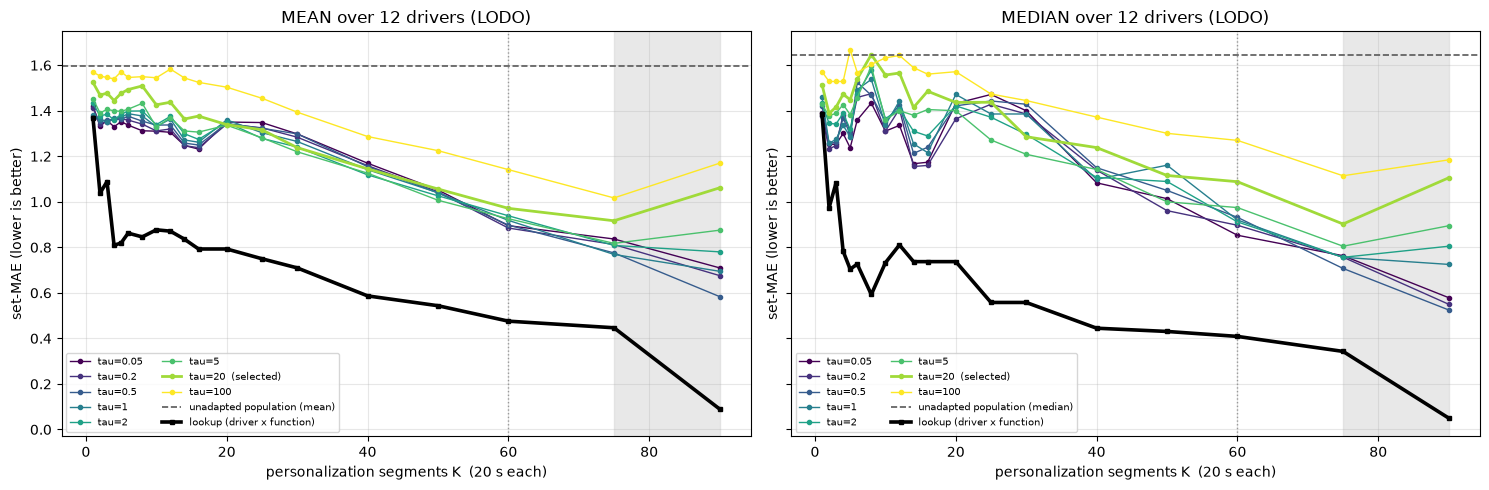

shaded: fewer than 12 drivers contribute (only the longest sessions reach K>60)


**mean vs median at tau=0.05** — a large gap means a skewed driver distribution at that K

,mean,median,mean - median
k,,,
1,1.420,1.388,0.032
2,1.333,1.252,0.081
3,1.357,1.254,0.103
4,1.330,1.300,0.030
5,1.352,1.237,0.115
6,1.337,1.359,-0.022
8,1.312,1.433,-0.122
10,1.310,1.310,-0.000
12,1.305,1.336,-0.031


In [28]:
SEL_TAU = 20.0     # what selected_tau.json recorded — see the caveat in the header
BEST_TAU = float(df[df.k <= K_CAP].groupby(["tau", "pid"]).set_mae.mean()
                 .groupby("tau").mean().idxmin())
print(f"selected tau = {SEL_TAU:g} (tie-break)   |   best tau by mean = {BEST_TAU:g}")

# MEAN and MEDIAN side by side. If a feature appears in one and not the other it
# is one driver, not a property of the cohort -- which is exactly what the
# K=16->20 bump turned out to be.
# The lookup aggregated the SAME way as the model curve in each panel -- a mean
# curve must be compared against a mean, a median against a median.
LK_MAE = {a: M.groupby("k").lk_set_mae.agg(a) for a in ("mean", "median")}
LK_ACC = {a: M.groupby("k").lk_set_acc.agg(a) for a in ("mean", "median")}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, agg in zip(axes, ("mean", "median")):
    plot_vs_k(df, "set_mae", "set-MAE (lower is better)",
              f"{agg.upper()} over {df.pid.nunique()} drivers (LODO)",
              floor=df.base_set_mae.agg(agg), floor_label=f"unadapted population ({agg})",
              selected_tau=SEL_TAU, ax=ax, min_drivers=12, agg=agg,
              reference=LK_MAE[agg], reference_label="lookup (driver x function)")
plt.tight_layout(); plt.show()
print("shaded: fewer than 12 drivers contribute (only the longest sessions reach K>60)")

# The gap between the two aggregations, at the best tau, is a direct read on how
# much any given point is being driven by one driver.
b = df[df.tau == BEST_TAU]
cmp = pd.DataFrame({"mean": b.groupby("k").set_mae.mean(),
                    "median": b.groupby("k").set_mae.median()})
cmp["mean - median"] = cmp["mean"] - cmp["median"]
display(Markdown(f"**mean vs median at tau={BEST_TAU:g}** — a large gap means a "
                 f"skewed driver distribution at that K"))
display(cmp.round(3))

---
## 2. The same curves MINUS the deployable lookup

Positive means the lookup is better. This is the plot that matters: the lookup
outscores the personalized model at every K on this cohort, so the live question is
not "who wins" but **whether the gap closes as labels accumulate**.

Each point is `model − lookup` differenced **within a driver at the same K**, then
averaged. Driver difficulty (per-driver floors span ~0.5–1.6) cancels exactly
rather than being averaged over, the same reason the arm comparison is paired.

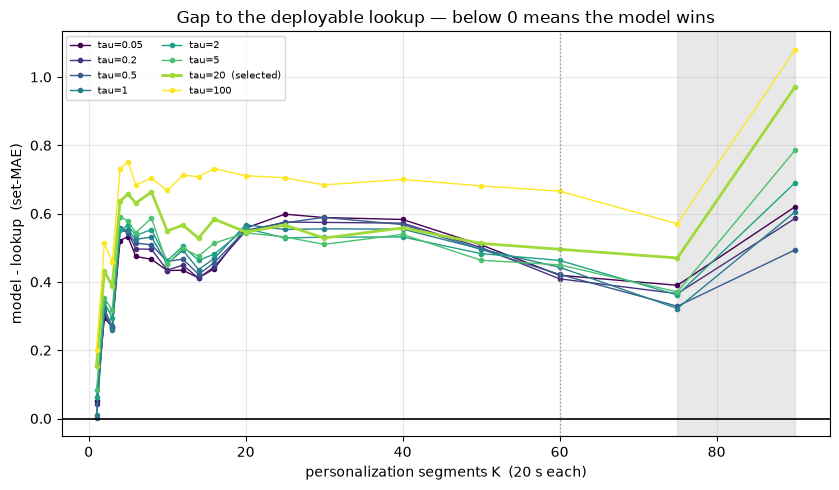

**Gap at tau=0.05 (best by mean)**

,model,lookup,gap,n
k,,,,
1,1.420,1.370,0.050,12
2,1.333,1.038,0.295,12
3,1.357,1.089,0.268,12
4,1.330,0.809,0.521,12
5,1.352,0.819,0.533,12
6,1.337,0.862,0.474,12
8,1.312,0.846,0.466,12
10,1.310,0.877,0.433,12
12,1.305,0.871,0.434,12


gap trend: +0.00328 per label  ->  not closing
Linear extrapolation of a learning curve is optimistic; the collected budget reaches K~60 (95 at most), so any crossover beyond that is untestable here.


In [29]:
M["gap_mae"] = M.set_mae - M.lk_set_mae      # >0 : lookup better

fig, ax = plt.subplots(figsize=(8.5, 5))
plot_vs_k(M.dropna(subset=["gap_mae"]), "gap_mae",
          "model - lookup  (set-MAE)",
          "Gap to the deployable lookup — below 0 means the model wins",
          zero_line=True, selected_tau=SEL_TAU, ax=ax, min_drivers=12)
plt.tight_layout(); plt.show()

g = M[(M.tau == BEST_TAU) & (M.k <= K_CAP)].dropna(subset=["gap_mae"])
tbl = g.groupby("k").agg(model=("set_mae", "mean"), lookup=("lk_set_mae", "mean"),
                         gap=("gap_mae", "mean"), n=("pid", "nunique"))
display(Markdown(f"**Gap at tau={BEST_TAU:g} (best by mean)**"))
display(tbl.round(3))
sl = np.polyfit(tbl.index.astype(float), tbl["gap"].values, 1)
print(f"gap trend: {sl[0]:+.5f} per label"
      + (f"  ->  extrapolates to zero at K={-sl[1]/sl[0]:.0f}" if sl[0] < 0
         else "  ->  not closing"))
print("Linear extrapolation of a learning curve is optimistic; the collected budget "
      "reaches K~60 (95 at most), so any crossover beyond that is untestable here.")

---
## 3. The same two views in set-ACCURACY

Higher is better, so the floor and the gap flip sign: a gap **below** zero now means
the lookup is better.

Worth reporting alongside MAE rather than instead of it. set-MAE is the design's
selection metric because LoA is ordinal and off-by-one is not off-by-four. But
set-accuracy is the fraction of predictions the driver marked *acceptable*, which is
the quantity the live study's satisfaction rating is closest to — a driver reacts to
whether the system chose something they would accept, not to the mean distance when
it did not.

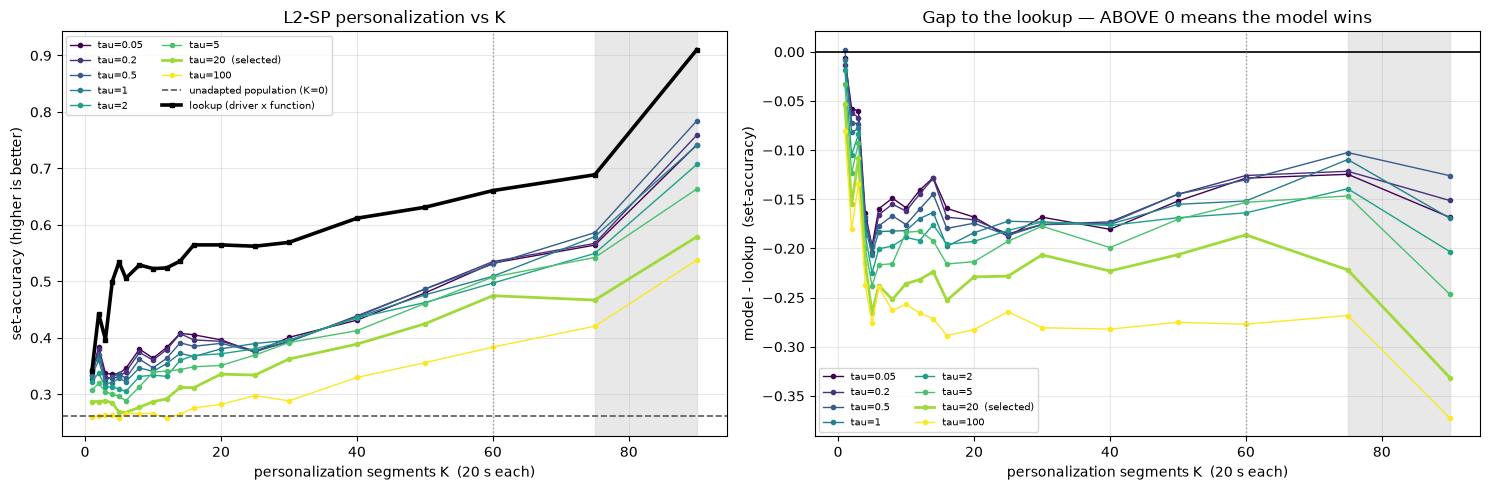

**Accuracy gap at tau=0.05**

,model,lookup,gap
k,,,
1,0.334,0.341,-0.006
2,0.385,0.442,-0.058
3,0.337,0.397,-0.060
4,0.336,0.500,-0.164
5,0.337,0.534,-0.198
6,0.346,0.506,-0.160
8,0.380,0.529,-0.149
10,0.364,0.523,-0.159
12,0.383,0.524,-0.141


accuracy gap trend: -0.00096 per label  ->  not closing


In [30]:
M["gap_acc"] = M.set_acc - M.lk_set_acc     # >0 : MODEL better (higher is better)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_vs_k(df, "set_acc", "set-accuracy (higher is better)",
          "L2-SP personalization vs K", floor=df.base_set_acc.mean(),
          floor_label="unadapted population (K=0)", selected_tau=SEL_TAU,
          ax=axes[0], min_drivers=12,
          reference=LK_ACC["mean"], reference_label="lookup (driver x function)")
plot_vs_k(M.dropna(subset=["gap_acc"]), "gap_acc",
          "model - lookup  (set-accuracy)",
          "Gap to the lookup — ABOVE 0 means the model wins",
          zero_line=True, selected_tau=SEL_TAU, ax=axes[1], min_drivers=12)
plt.tight_layout(); plt.show()

ga = M[(M.tau == BEST_TAU) & (M.k <= K_CAP)].dropna(subset=["gap_acc"])
t2 = ga.groupby("k").agg(model=("set_acc", "mean"), lookup=("lk_set_acc", "mean"),
                         gap=("gap_acc", "mean"))
display(Markdown(f"**Accuracy gap at tau={BEST_TAU:g}**"))
display(t2.round(3))
sl2 = np.polyfit(t2.index.astype(float), t2["gap"].values, 1)
print(f"accuracy gap trend: {sl2[0]:+.5f} per label"
      + (f"  ->  reaches zero at K={-sl2[1]/sl2[0]:.0f}" if sl2[0] > 0 else "  ->  not closing"))

---
## 4. Per-driver curves at the best tau

The pooled curve hides everything that matters about heterogeneity. Per-driver
set-MAE at a given K spans roughly 0.4 to 2.2 on this cohort, so:

* a single driver's excursion is visible in the mean at about a tenth of its own
  size — which is the whole of the K=16→20 "bump" (driver 007 alone);
* "how many labels does a driver need" almost certainly has no single answer, and
  the spread of these curves is the honest version of that question;
* if personalization helps some drivers and hurts others, only this view shows it.

Both metrics are plotted because they disagree in a useful way: set-MAE is the
selection metric (LoA is ordinal, so off-by-one is not off-by-four), while
set-accuracy is the fraction of predictions the driver marked acceptable — closer
to what the live study's satisfaction rating measures.

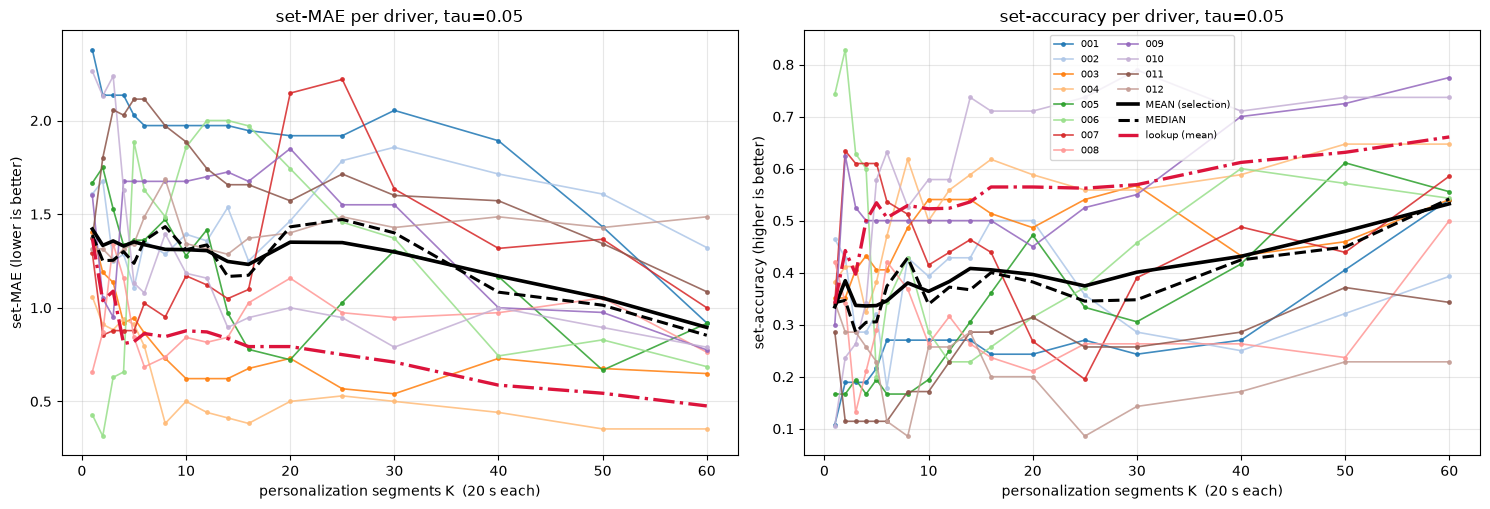

**Per-driver trend over K=20-60 at tau=0.05** (negative mae_slope = improving)

,pid,mae@20,mae@60,mae_slope,acc@20,acc@60,acc_slope,floor(K=0)
0,007,2.1463,1.0000,-0.0292,0.2683,0.5854,0.0083,2.1951
1,006,1.7429,0.6857,-0.0264,0.3143,0.5429,0.0061,1.8571
2,009,1.8500,0.7750,-0.0263,0.4500,0.7750,0.0082,1.3000
3,001,1.9189,0.9189,-0.0250,0.2432,0.5405,0.0071,1.2973
4,011,1.5714,1.0857,-0.0133,0.3143,0.3429,0.0020,1.7143
5,002,1.4643,1.3214,-0.0065,0.5000,0.3929,-0.0016,1.7500
6,008,1.1579,0.7632,-0.0057,0.2105,0.5000,0.0050,1.1053
7,004,0.5000,0.3529,-0.0048,0.5882,0.6471,0.0022,1.0000
8,010,1.0000,0.7895,-0.0032,0.7105,0.7368,-0.0000,2.0789
9,005,0.7222,0.9167,-0.0029,0.4722,0.5556,0.0054,2.0278


improving on set-MAE : 10/12 drivers
improving on set-acc : 9/12 drivers
per-driver set-MAE at K=60 spans 0.35 to 1.49 — the spread the pooled curve averages away


In [31]:
# ------------------------------- per-driver curves at the best tau

def plot_per_driver(data: pd.DataFrame, tau: float, k_max: int = K_CAP):
    """One line per driver for set-MAE and set-accuracy, at a single tau.

    Restricted to K <= k_max because past 60 only three drivers have data, and a
    line that stops early reads as a driver who got worse rather than one who ran
    out of labels.

    The cohort mean and median are drawn over the top in black so the individual
    spread can be compared against the number the tau selection actually used.
    """
    b = data[(data.tau == tau) & (data.k <= k_max)]
    if b.empty:
        print("(no rows at that tau)")
        return
    pids = sorted(b.pid.unique())
    cmap = plt.get_cmap("tab20")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    for j, (col, ylab, better) in enumerate(
            (("set_mae", "set-MAE", "lower"), ("set_acc", "set-accuracy", "higher"))):
        ax = axes[j]
        for i, pid in enumerate(pids):
            g = b[b.pid == pid].sort_values("k")
            ax.plot(g.k, g[col], color=cmap(i % 20), lw=1.2, marker="o", ms=2.5,
                    alpha=.85, label=pid)
        m = b.groupby("k")[col].mean()
        md_ = b.groupby("k")[col].median()
        ax.plot(m.index, m.values, c="k", lw=2.6, label="MEAN (selection)")
        ax.plot(md_.index, md_.values, c="k", lw=2.2, ls="--", label="MEDIAN")
        # The lookup's cohort mean, so the per-driver spread can be read against
        # the thing the model has to beat rather than only against itself.
        lk_col = "lk_set_mae" if col == "set_mae" else "lk_set_acc"
        lkm = M[(M.tau == tau) & (M.k <= k_max)].groupby("k")[lk_col].mean()
        ax.plot(lkm.index, lkm.values, c="crimson", lw=2.4, ls="-.",
                label="lookup (mean)")
        ax.set_xlabel("personalization segments K  (20 s each)")
        ax.set_ylabel(f"{ylab} ({better} is better)")
        ax.set_title(f"{ylab} per driver, tau={tau:g}")
        ax.grid(alpha=.3)
    axes[1].legend(fontsize=7, ncol=2, loc="best")
    plt.tight_layout(); plt.show()


plot_per_driver(df, BEST_TAU)

# Who improves and who does not. `slope` is a straight-line fit over the
# DEPLOYABLE range only: below ~K=20 both the model and the lookup are still
# degenerate, and including that region makes every slope look positive.
b = df[(df.tau == BEST_TAU) & (df.k >= 20) & (df.k <= K_CAP)]
rows = []
for pid, g in b.groupby("pid"):
    g = g.sort_values("k")
    rows.append({"pid": pid,
                 "mae@20": g.set_mae.iloc[0], "mae@60": g.set_mae.iloc[-1],
                 "mae_slope": np.polyfit(g.k.astype(float), g.set_mae, 1)[0],
                 "acc@20": g.set_acc.iloc[0], "acc@60": g.set_acc.iloc[-1],
                 "acc_slope": np.polyfit(g.k.astype(float), g.set_acc, 1)[0],
                 "floor(K=0)": g.base_set_mae.iloc[0]})
per = pd.DataFrame(rows).sort_values("mae_slope").reset_index(drop=True)
display(Markdown(f"**Per-driver trend over K=20-60 at tau={BEST_TAU:g}** "
                 f"(negative mae_slope = improving)"))
display(per.round(4))
print(f"improving on set-MAE : {(per.mae_slope < 0).sum()}/{len(per)} drivers")
print(f"improving on set-acc : {(per.acc_slope > 0).sum()}/{len(per)} drivers")
print(f"per-driver set-MAE at K=60 spans {per['mae@60'].min():.2f} to "
      f"{per['mae@60'].max():.2f} — the spread the pooled curve averages away")

---
## 5. How much of the pooled curve is one driver?

The median turns out to be a poor robust summary here, and it is worth saying why:
at n=12 it is the average of the 6th and 7th order statistics, and with per-driver
set-MAE spanning ~0.4 to ~2.2 those two neighbours can be far apart. A driver
crossing the middle of the ranking moves the median discontinuously, so it reads
*noisier* than the mean rather than smoother. My earlier suggestion that it is the
more robust view of the shape was wrong for this sample size.

Two better options, both plotted below:

* **Trimmed mean** (drop the highest and lowest driver at each K). Principled — it
  names no driver and applies the same rule everywhere — and continuous, so it does
  not jump the way the median does.
* **Excluding driver 007 specifically.** This is a SENSITIVITY CHECK, not a
  reported number. 007 produced the entire K=16→20 bump (1.122 → 2.171, moving the
  cohort mean by +0.087 out of +0.095) and is also the steepest *improver* over
  K=20–60. Dropping a driver after seeing that they are inconvenient is exactly the
  kind of post-hoc choice that has to be shown alongside the full-cohort number,
  never instead of it.

If the trimmed mean and the full mean agree, the pooled curve is not being driven
by any one driver and the shape can be read as a cohort property.

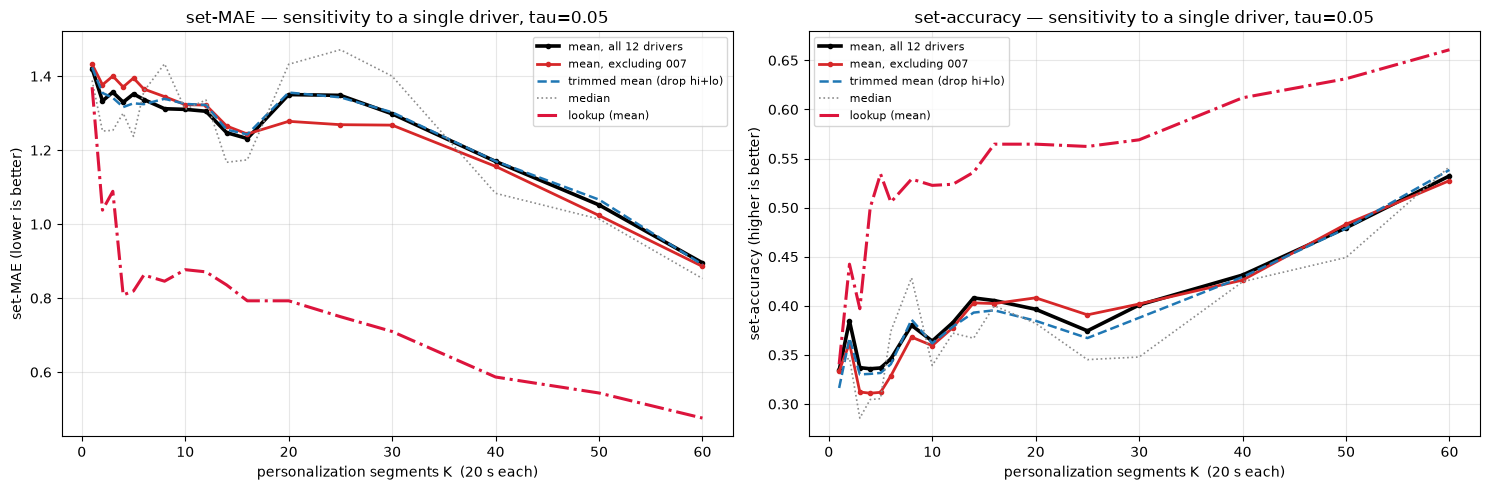

**Leave-one-driver-out sensitivity at tau=0.05** — `max_1driver_shift` is the largest change any single driver causes at that K

,mean,excl_007,trimmed,median,max_1driver_shift,driver
k,,,,,,
1,1.420,1.432,1.424,1.388,0.090,006
2,1.333,1.377,1.355,1.252,0.093,006
3,1.357,1.400,1.341,1.254,-0.080,010
4,1.330,1.371,1.316,1.300,-0.073,001
5,1.352,1.395,1.327,1.237,-0.069,011
6,1.337,1.365,1.324,1.359,-0.071,011
8,1.312,1.345,1.339,1.433,0.085,004
10,1.310,1.323,1.325,1.310,0.074,004
12,1.305,1.322,1.322,1.336,0.079,004


set-MAE slope over K=20-60:  all -0.01179 | excl 007 -0.01021 | trimmed -0.01178
largest single-driver shift anywhere in K<= 60: 0.093 (driver 006 at K=2)
If the three summaries give the same slope, the downward trend is a cohort property and not one driver's curve.


In [32]:
# ------------------- leave-one-out / trimmed sensitivity at the best tau

def trimmed_mean(s: pd.Series, n_trim: int = 1) -> float:
    """Mean after dropping the n_trim highest and lowest values.

    Named no driver, applied identically at every K -- which is what makes it a
    summary rather than an exclusion. Continuous in the data, unlike the median.
    """
    v = np.sort(s.dropna().to_numpy())
    return float(v[n_trim:-n_trim].mean()) if len(v) > 2 * n_trim else float(v.mean())


EXCLUDE = "007"          # the driver identified in section 4, named explicitly
b = df[(df.tau == BEST_TAU) & (df.k <= K_CAP)]
b_ex = b[b.pid != EXCLUDE]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, ylab, better in ((axes[0], "set_mae", "set-MAE", "lower"),
                              (axes[1], "set_acc", "set-accuracy", "higher")):
    full = b.groupby("k")[col].mean()
    excl = b_ex.groupby("k")[col].mean()
    trim = b.groupby("k")[col].apply(trimmed_mean)
    med = b.groupby("k")[col].median()
    ax.plot(full.index, full.values, c="k", lw=2.6, marker="o", ms=3,
            label=f"mean, all {b.pid.nunique()} drivers")
    ax.plot(excl.index, excl.values, c="tab:red", lw=2.0, marker="o", ms=3,
            label=f"mean, excluding {EXCLUDE}")
    ax.plot(trim.index, trim.values, c="tab:blue", lw=1.8, ls="--",
            label="trimmed mean (drop hi+lo)")
    ax.plot(med.index, med.values, c="0.55", lw=1.2, ls=":", label="median")
    lk_col = "lk_set_mae" if col == "set_mae" else "lk_set_acc"
    lkm = M[(M.tau == BEST_TAU) & (M.k <= K_CAP)].groupby("k")[lk_col].mean()
    ax.plot(lkm.index, lkm.values, c="crimson", lw=2.2, ls="-.", label="lookup (mean)")
    ax.set_xlabel("personalization segments K  (20 s each)")
    ax.set_ylabel(f"{ylab} ({better} is better)")
    ax.set_title(f"{ylab} — sensitivity to a single driver, tau={BEST_TAU:g}")
    ax.grid(alpha=.3)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# How much any ONE driver can move the pooled curve: the largest shift produced by
# dropping a single driver, at each K. This is the honest error bar on reading a
# local feature, and it is computed over EVERY driver rather than the one we noticed.
loo = []
for k, g in b.groupby("k"):
    full = g.set_mae.mean()
    shifts = {p: g[g.pid != p].set_mae.mean() - full for p in g.pid.unique()}
    worst = max(shifts, key=lambda p: abs(shifts[p]))
    loo.append({"k": k, "mean": full, "excl_007": g[g.pid != EXCLUDE].set_mae.mean(),
                "trimmed": trimmed_mean(g.set_mae), "median": g.set_mae.median(),
                "max_1driver_shift": shifts[worst], "driver": worst})
loo = pd.DataFrame(loo).set_index("k")
display(Markdown(f"**Leave-one-driver-out sensitivity at tau={BEST_TAU:g}** — "
                 f"`max_1driver_shift` is the largest change any single driver "
                 f"causes at that K"))
display(loo.round(3))

sl_all = np.polyfit(*(lambda t: (t.index.astype(float), t.values))(
    b[b.k >= 20].groupby("k").set_mae.mean()), 1)[0]
sl_ex = np.polyfit(*(lambda t: (t.index.astype(float), t.values))(
    b_ex[b_ex.k >= 20].groupby("k").set_mae.mean()), 1)[0]
sl_tr = np.polyfit(*(lambda t: (t.index.astype(float), t.values))(
    b[b.k >= 20].groupby("k").set_mae.apply(trimmed_mean)), 1)[0]
print(f"set-MAE slope over K=20-60:  all {sl_all:+.5f} | excl {EXCLUDE} {sl_ex:+.5f} "
      f"| trimmed {sl_tr:+.5f}")
print(f"largest single-driver shift anywhere in K<= {K_CAP}: "
      f"{loo.max_1driver_shift.abs().max():.3f} "
      f"(driver {loo.loc[loo.max_1driver_shift.abs().idxmax(), 'driver']} at "
      f"K={loo.max_1driver_shift.abs().idxmax()})")
print("If the three summaries give the same slope, the downward trend is a cohort "
      "property and not one driver's curve.")

In [33]:
# ------------------------------------------------- convergence check

conv = df.assign(ok=df.grad_norm <= GRAD_OK)
display(Markdown("**Converged fraction by (tau, K)** — 1.00 is what the Laplace "
                 "layer needs; the expansion is taken about the MAP"))
pv = conv.pivot_table(index="tau", columns="k", values="ok", aggfunc="mean")
display(pv.round(2))
bad = pv.min(axis=1)
print("taus whose worst K is fully converged:",
      [f"{t:g}" for t in bad.index[bad == 1.0]] or "NONE")
print(f"\nAt the best-by-mean tau={BEST_TAU:g}, converged cells at K>=40: "
      f"{conv[(conv.tau == BEST_TAU) & (conv.k >= 40)].ok.mean():.0%}")
print("Any conclusion resting on the large-K end of a low tau is provisional until "
      "the sweep is re-run with a larger --steps budget.")

**Converged fraction by (tau, K)** — 1.00 is what the Laplace layer needs; the expansion is taken about the MAP

k,1,2,3,4,5,6,8,10,12,14,16,20,25,30,40,50,60,75,90
tau,,,,,,,,,,,,,,,,,,,
0.05,1.00,1.00,1.00,0.92,1.00,1.00,1.00,0.92,0.83,0.83,0.83,0.67,0.50,0.25,0.17,0.00,0.08,0.00,0.00
0.20,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.83,0.75,0.45,0.33
0.50,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2.00,0.83,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
5.00,0.50,0.67,0.92,0.75,1.00,0.92,1.00,1.00,0.83,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
20.00,0.00,0.08,0.00,0.25,0.08,0.17,0.33,0.58,0.75,0.67,0.92,0.75,1.00,0.92,1.00,1.00,1.00,1.00,1.00
100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08,0.00,0.17,0.08,0.25,0.58,0.67,0.45,0.67


taus whose worst K is fully converged: ['0.5', '1']

At the best-by-mean tau=0.05, converged cells at K>=40: 6%
Any conclusion resting on the large-K end of a low tau is provisional until the sweep is re-run with a larger --steps budget.


---
## 6. Plain head vs FCD-augmented head

Two runs of stage 3 differing in `--embed-fcd` and nothing else: same LODO
checkpoints, same tau grid, same `--val-frac`, same step budget. Set the two paths
below; the section is skipped if only one exists.

**Why this is a much stronger test than the population sweep's.** There the FCD
effect rested on 18 paired cells (−0.028, t=−2.28). Here every `(pid, tau, k)` cell
appears in both runs, giving ~12 × 8 × 19 ≈ 1800 pairs. Differencing within a cell
cancels driver difficulty, tau and budget exactly, which is what makes it possible
to ask the interesting question — does FCD access help **more at large K**? If the
mechanism is "the head can express per-function preference", the benefit should grow
as more functions accumulate in the support, and that is testable per-K here.

**Provenance.** Runs produced after 2026-08-18 carry `embed_fcd` and `head_in`
columns; `head_in` is read off the head itself, so a file cannot disagree with what
was actually adapted. Older files have neither — `--embed-fcd` widens the head only
in memory, the on-disk checkpoints stay narrow, so there is no way to recover the
setting after the fact. The loader below checks the column when present and warns
when it has to trust the filename instead.

In [ ]:
# ------------------------- paired comparison: plain vs FCD-augmented

PLAIN_CSV = ROOT / "results/l2sp_sweep_plain/l2sp_tau_sweep.csv"
FCD_CSV   = ROOT / "results/l2sp_sweep_fcd/l2sp_tau_sweep.csv"


def load_arm_csv(path: pathlib.Path, expect_fcd: int, name: str):
    """One stage-3 CSV, with its embed_fcd setting VERIFIED where possible."""
    if not path.exists():
        print(f"[{name}] not found: {path}")
        return None
    d = pd.read_csv(path, dtype={"pid": str})
    if "embed_fcd" in d.columns:
        got = sorted(d.embed_fcd.dropna().unique())
        if got != [expect_fcd]:
            print(f"[{name}] WARNING: file says embed_fcd={got}, expected "
                  f"[{expect_fcd}] — the paths are probably swapped.")
        else:
            print(f"[{name}] embed_fcd={expect_fcd} confirmed from the file "
                  f"(head_in={sorted(d.head_in.unique()) if 'head_in' in d else '?'})")
    else:
        print(f"[{name}] no embed_fcd column (run predates it) — trusting the path. "
              f"This is exactly the ambiguity the column was added to remove.")
    return d


A = load_arm_csv(PLAIN_CSV, 0, "plain")
B = load_arm_csv(FCD_CSV, 1, "fcd")

if A is None or B is None:
    print("\nOne of the two runs is missing — section skipped. Produce both with:")
    print("  sweep_l2sp_tau --outdir results/l2sp_sweep_plain --steps 6000")
    print("  sweep_l2sp_tau --outdir results/l2sp_sweep_fcd   --steps 6000 --embed-fcd")
    print("They must share the SAME LODO checkpoints and --val-frac, or the pairing "
          "is not a pairing.")
else:
    key = ["pid", "tau", "k"]
    P = (A[key + ["set_mae", "set_acc"]]
         .merge(B[key + ["set_mae", "set_acc"]], on=key, suffixes=("_plain", "_fcd")))
    P["d_mae"] = P.set_mae_fcd - P.set_mae_plain      # <0 : FCD better
    P["d_acc"] = P.set_acc_fcd - P.set_acc_plain      # >0 : FCD better
    print(f"\n{len(P)} paired cells over {P.pid.nunique()} drivers, "
          f"{P.tau.nunique()} taus, {P.k.nunique()} K values")

    def paired(x, better_negative=True):
        se = x.std(ddof=1) / np.sqrt(len(x))
        return x.mean(), se, (x.mean() / se if se else np.nan)

    for nm, col, negbetter in (("set-MAE", "d_mae", True), ("set-acc", "d_acc", False)):
        m, se, t = paired(P[col])
        win = (P[col] < 0).mean() if negbetter else (P[col] > 0).mean()
        print(f"  {nm:8} FCD - plain = {m:+.4f} +/- {se:.4f} (t={t:+.1f}); "
              f"FCD better in {win:.0%} of cells")

    # DOES IT HELP MORE AT LARGE K? The reason for pairing per cell rather than
    # only in aggregate: the mechanism predicts a trend, not just a mean.
    byk = P[P.k <= K_CAP].groupby("k").agg(
        d_mae=("d_mae", "mean"), d_acc=("d_acc", "mean"), n=("pid", "size"))
    display(Markdown("**FCD advantage by K** (negative d_mae / positive d_acc = FCD better)"))
    display(byk.round(4))
    sl = np.polyfit(byk.index.astype(float), byk.d_mae.values, 1)[0]
    print(f"trend in the MAE advantage: {sl:+.5f} per label"
          + ("  -> FCD helps MORE as labels accumulate" if sl < 0
             else "  -> the advantage does not grow with K"))

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    for ax, col, ylab in ((axes[0], "d_mae", "set-MAE:  FCD - plain"),
                          (axes[1], "d_acc", "set-acc:  FCD - plain")):
        for tau in sorted(P.tau.unique()):
            c = P[(P.tau == tau) & (P.k <= K_CAP)].groupby("k")[col].mean()
            ax.plot(c.index, c.values, lw=1.2, marker="o", ms=3, label=f"tau={tau:g}")
        allk = P[P.k <= K_CAP].groupby("k")[col].mean()
        ax.plot(allk.index, allk.values, c="k", lw=2.6, label="all taus")
        ax.axhline(0, c="k", lw=1.0)
        ax.set_xlabel("K"); ax.set_ylabel(ylab); ax.grid(alpha=.3)
        ax.set_title(ylab + ("  (below 0 = FCD wins)" if col == "d_mae"
                             else "  (above 0 = FCD wins)"))
        ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

---
## 7. Both tau sweeps in one picture

The two runs were launched to answer opposite halves of the same question and
neither can answer it alone:

* the **first** spanned tau 0.05–100 and showed the top end is bad — tau=100 is
  clearly worse at every K;
* the **second** extended downward to 0.005 and showed the bottom end is flat —
  three orders of magnitude of tau move the mean by 0.036.

Together they cover 0.005–100, which is the range the write-up should show.

**They are mergeable, and this is checked rather than assumed.** The two runs share
five tau values, and on those the results agree: 79 of 1090 shared cells differ at
all, mean difference −0.0004, and tau=1.0 is bit-identical. The differing cells are
the ones that did not converge, landing slightly differently — `run_one`'s docstring
already warns that CPU reduction order depends on thread count, so a different
machine or `--threads-per-job` reproduces to about this tolerance. The K=0 floor is
identical to full precision, which is the real check: same LODO checkpoints, same
tail, same `--val-frac`.

Shared taus are taken from the EXTENDED run and the original contributes only
{5, 20, 100}, so no cell is counted twice and the seam sits where the runs are
known to agree.

**The tau-response panel is the one to put in the thesis.** A K-curve with twelve
tau lines shows that tau does little, but says it badly; mean set-MAE against tau on
a log axis says it directly. The second panel plots the converged fraction on the
same axis, because the choice is a trade: the paired minimum is at the bottom of the
grid, while convergence is best at tau≈0.02–0.05, and an unconverged head is not
merely undertrained — the Laplace layer expands about the MAP.

In [ ]:
# --------------------------- merge the two tau sweeps

RUNS = [   # (path, label, priority) -- higher priority wins a shared tau
    (ROOT / "results/l2sp_sweep_fcd_extend/l2sp_tau_sweep.csv", "extended (0.005-2)", 2),
    (ROOT / "results/l2sp_sweep/l2sp_tau_sweep.csv",            "original (0.05-100)", 1),
]


def merge_runs(runs, tol: float = 0.25):
    """Concatenate tau sweeps, keeping one row per (pid, tau, k).

    Two things are VERIFIED rather than assumed, because a silent mismatch here
    would put two different experiments on one axis:

      * the K=0 floor per driver must be identical across runs -- that is the
        signature of the same LODO checkpoints and the same evaluation tail;
      * on shared taus the adapted scores must agree to `tol`. They will not be
        bit-identical: unconverged cells land differently under a different
        thread count (see sweep_population_hparams.run_one), so a small tolerance
        is expected and a large disagreement is not.
    """
    frames = []
    for path, label, prio in sorted(runs, key=lambda r: -r[2]):
        if not path.exists():
            print(f"[skip] {label}: {path} not found")
            continue
        d = pd.read_csv(path, dtype={"pid": str})
        d["run"] = label
        d["_prio"] = prio
        frames.append(d)
        print(f"[load] {label}: {len(d)} rows, taus {sorted(d.tau.unique())}")
    if not frames:
        return None
    all_ = pd.concat(frames, ignore_index=True)

    # check 1 -- same checkpoints / same tail
    fl = all_.groupby(["run", "pid"]).base_set_mae.first().unstack(0)
    if fl.shape[1] > 1:
        gap = (fl.max(axis=1) - fl.min(axis=1)).abs().max()
        print(f"[check] K=0 floor agrees across runs to {gap:.2e} "
              + ("-> same checkpoints" if gap < 1e-9
                 else "-> DIFFERENT checkpoints, do NOT merge"))
        if gap >= 1e-9:
            return None

    # check 2 -- shared taus agree
    dup = all_.duplicated(subset=["pid", "tau", "k"], keep=False)
    if dup.any():
        s = all_[dup].pivot_table(index=["pid", "tau", "k"], columns="run",
                                  values="set_mae")
        diff = (s.max(axis=1) - s.min(axis=1)).abs()
        print(f"[check] {len(s)} shared cells: {(diff > 1e-9).sum()} differ, "
              f"mean {diff.mean():+.4f}, max {diff.max():.3f}")
        if diff.max() > tol:
            print(f"[check] WARNING max disagreement {diff.max():.3f} > {tol} — "
                  f"more than unconverged-cell noise; inspect before trusting.")

    out = (all_.sort_values("_prio", ascending=False)
                .drop_duplicates(subset=["pid", "tau", "k"], keep="first")
                .drop(columns="_prio").reset_index(drop=True))
    print(f"[merge] {len(out)} rows, taus {sorted(out.tau.unique())}")
    return out


ALL = merge_runs(RUNS)

In [ ]:
# --------------------------- the two combined figures

if ALL is not None:
    import matplotlib.colors as mcolors
    taus = sorted(ALL.tau.unique())
    norm = mcolors.LogNorm(vmin=min(taus), vmax=max(taus))
    cmap = plt.get_cmap("coolwarm")

    # ---- FIGURE 1: K curve, every tau from both runs on one axis --------
    fig, ax = plt.subplots(figsize=(9.5, 5.4))
    for t in taus:
        c = ALL[(ALL.tau == t) & (ALL.k <= K_CAP)].groupby("k").set_mae.mean()
        ax.plot(c.index, c.values, color=cmap(norm(t)), lw=1.6, marker="o", ms=3,
                label=f"tau={t:g}")
    ax.plot(LK_MAE["mean"].index[LK_MAE["mean"].index <= K_CAP],
            LK_MAE["mean"][LK_MAE["mean"].index <= K_CAP].values,
            c="k", lw=2.8, marker="s", ms=4, zorder=5, label="lookup (driver x function)")
    ax.axhline(ALL.base_set_mae.mean(), ls="--", c="0.35", lw=1.2,
               label="unadapted population (K=0)")
    ax.set_xlabel("personalization segments K  (20 s each)")
    ax.set_ylabel("set-MAE (lower is better)")
    ax.set_title("Both tau sweeps combined — colour is log(tau), blue = small")
    ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

    # ---- FIGURE 2: the tau response, which is the actual question ------
    cap = ALL[ALL.k <= K_CAP]
    per = cap.groupby(["tau", "pid"]).set_mae.mean().groupby("tau").agg(["mean", "std", "count"])
    per["se"] = per["std"] / np.sqrt(per["count"])
    conv = ALL.assign(ok=ALL.grad_norm <= GRAD_OK).groupby("tau").ok.mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].errorbar(per.index, per["mean"], yerr=per["se"], marker="o", lw=1.8,
                     capsize=3, color="tab:blue")
    best = per["mean"].idxmin()
    axes[0].axhline(per["mean"].min() + per.loc[best, "se"], ls=":", c="0.5",
                    label="1 SE above the minimum")
    axes[0].axvline(best, ls="--", c="tab:green", label=f"paired minimum (tau={best:g})")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("tau  (prior precision, log scale)")
    axes[0].set_ylabel(f"mean set-MAE over K <= {K_CAP}")
    axes[0].set_title("tau response — flat below ~1, degrades above")
    axes[0].grid(alpha=.3, which="both"); axes[0].legend(fontsize=8)

    axes[1].plot(conv.index, conv.values, marker="o", lw=1.8, color="tab:red")
    axes[1].axhline(1.0, ls=":", c="0.5")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("tau  (prior precision, log scale)")
    axes[1].set_ylabel(f"fraction of cells with |grad| <= {GRAD_OK:g}")
    axes[1].set_title("convergence — the other half of the choice")
    axes[1].grid(alpha=.3, which="both")
    plt.tight_layout(); plt.show()

    tbl = pd.DataFrame({"mean_set_mae": per["mean"], "se": per["se"],
                        "converged": conv}).round(4)
    display(Markdown(f"**tau response over the combined range** "
                     f"({per['count'].max():.0f} drivers, K <= {K_CAP})"))
    display(tbl)
    print(f"spread across the WHOLE grid: {per['mean'].max() - per['mean'].min():.4f}")
    print(f"between-driver sd:            {cap.groupby('pid').set_mae.mean().std(ddof=1):.4f}")
    print("-> tau is a tenth-order effect next to which driver you got. Choose it for "
          "convergence, not for the mean.")

---
## Limitations

1. **tau here is not the committed tau.** `selected_tau.json` records the tie-break
   winner, not the minimum. Fix the tie-break to a paired statistic — or re-run with
   a grid extended below 0.05 — before quoting a value.
2. **Convergence.** 22 % of cells exceed the gradient threshold, worst at the extreme
   taus. This invalidates the Laplace posterior for those cells, not just their point
   estimates.
3. **The lookup is a moving target.** It improves with K too, so "the model reaches
   the lookup's K=60 score at K=X" is not a crossover. The gap curve above is the
   honest version; read that, not the two levels separately.
4. **Extrapolation.** No saturation is visible by K=60, which is informative — the
   collected budget sits on the steep part of the curve — but a linear extrapolation
   past the data is not evidence that the curves ever meet.
5. **Above K=60 the cohort changes.** Only the longest sessions reach K=75/90, so the
   shaded region is a different and smaller set of drivers.